## `make_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `results_methods.py`

In [ ]:
import numpy as np 
import fitsio as fio 
import pandas as pd 
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from pathlib import Path
from pycorr import TwoPointEstimator
from scipy.integrate import simpson

import src.statistics.results_methods as resm
import src.statistics.corrutils as cu
import src.statistics.corrfiles as cf

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [41]:
importlib.reload(resm)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
desc = 'j64_ns256'
path_dictionary = {
    'HSC' : ROOT / 'results_hsc' / f'minibins_{desc}_sp0_04', #quasar spacing bla bla bla
    'DESI_NGC' : ROOT / 'results_nonKP_FKP' / f'autos_{desc}_NGC',
    'DESI_SGC' : None, #ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT / 'results_nonKP_FKP' / f'cross_{desc}_zbin',
}
for v in path_dictionary.values():
    if v is not None:
        assert Path(v).is_dir(), f"Path {v} does not exist as a directory. Please check the path."

In [42]:
## get sigmaj corrections
sims = False
if sims:
    catalog = fio.FITS('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/sims/v5/hscy3_sim_v5.fits')[1]
    zcat = catalog['Z'].read()
else:
    catalog = fio.FITS('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits')[1]
    zcat = catalog['dnnz_photoz_best'].read()

/tmp/ipykernel_2071757/2884729999.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


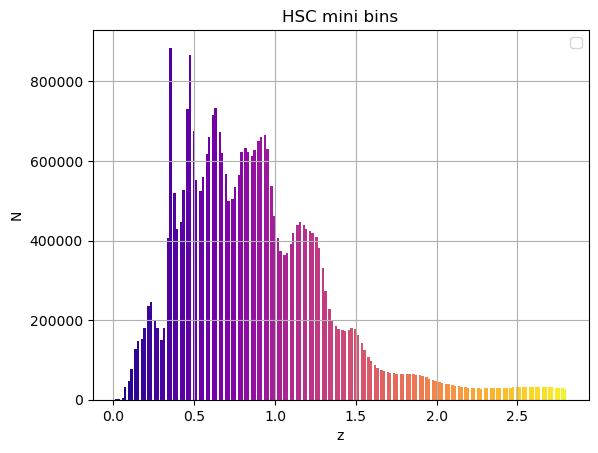

In [43]:
# hsc mini bins
mini_hsc = cf.CorrFileReader(path_dictionary['HSC']).get_bins('HSC')
colormap = plt.get_cmap('plasma')
# get sigmaj for two adjacents bins (std of redshift distribution in the bin ...)
sigmaj_corr = []
zmid = []
for i in range(1, len(mini_hsc)):
    z_bin = zcat[(zcat > mini_hsc[i-1]) & (zcat <= mini_hsc[i])]
    zmid.append(np.mean(z_bin))
    # careful : it's 1/std of the redshift distribution in the bin
    sigmaj_corr.append(np.std(z_bin))
    plt.hist(
        z_bin, 
        bins=2, 
        color=colormap(i/len(mini_hsc)),
        )
plt.xlabel('z')
plt.ylabel('N')
plt.title('HSC mini bins')
plt.grid()
plt.legend()

Text(0.5, 1.0, '$\\sigma_j$ corrections for minibins_j64_ns256_sp0_04')

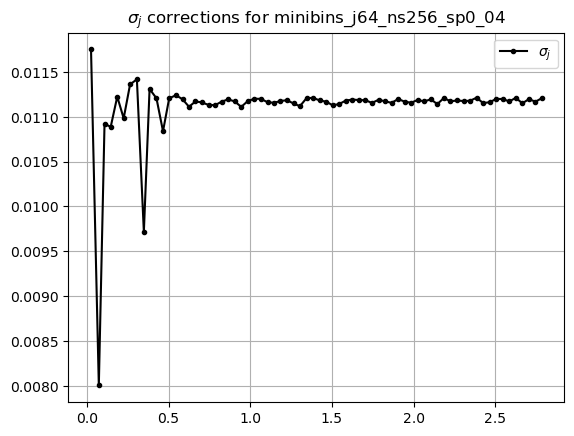

In [44]:
plt.plot(zmid, np.array(sigmaj_corr), marker='o', markersize=3, color='black', label=r'$\sigma_j$')
plt.legend()
plt.grid()
plt.title(r'$\sigma_j$' + f' corrections for {Path(path_dictionary["HSC"]).name}')

In [49]:
importlib.reload(resm)
tracer = 'ELGnotqso'
mode = 'DES'
nz = []
for i in range(1, 5):
    kwargs = {
        'path_dictionary' : path_dictionary,
        'scale_cuts' : [0.5, 5.0],
        'tracer' : tracer,
        'tomo_bin' : i,
        'sigmaj_corrections' : np.ones_like(sigmaj_corr),
        'verbose' : True,
    }
    print(f"Computing n(z) for tracer {tracer} and tomo bin {i}")
    nz.append(
        resm.full_npz_tomo(
            **kwargs
            )
    )

Computing n(z) for tracer ELGnotqso and tomo bin 1
fine_redshift : [0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08 1.12 1.16 1.2  1.24 1.28 1.32
 1.36 1.4  1.44 1.48 1.52 1.56 1.6 ]
hsc_redshift : [0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.   2.04 2.08 2.12 2.16 2.2
 2.24 2.28 2.32 2.36 2.4  2.44 2.48 2.52 2.56 2.6  2.64 2.68 2.72 2.76
 2.8 ]
hsc_bins that match fine_redshift : [20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]
sigmaj_corrections :  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 70
B : 1.7290, 1.0434, prodsqrt : 1.3719, num : 0.1417, num_no_b : 0.1055
B : 1.7670, 1.0659, prodsqrt : 1.4169,

(-2.0, 8.0)

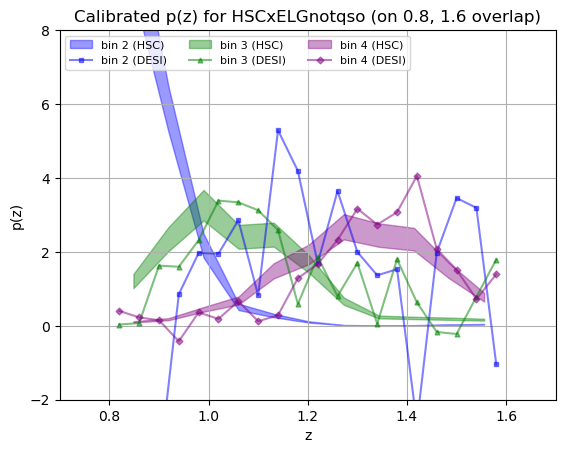

In [50]:
bins_tracer = cf.CorrFileReader(
    path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
bins_hsc = np.arange(0.3, 1.8, 0.3)
colors = ['red', 'blue', 'green', 'purple']
markers = ['x', 's', '^', 'D']
zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
mids = tomo_bin_dnnz[mask, 0]

dnnz_list = []
mu_list = []
cov_list = []
ids_to_skip = []
range_tracer = [bins_tracer[0], bins_tracer[-1]]

for i in range(4):
    if max(range_tracer[0], bins_hsc[i]) > min(range_tracer[1], bins_hsc[i+1]):
        ids_to_skip.append(i)
ncurves = 0
for i in range(4):
    if i in ids_to_skip:
        #pass
        continue
    ncurves += 1

    dnnz, mu, cov = resm.hsc_dnnz_error(tomo_bin_dnnz[mask, i+1], mids)

    plt.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colors[i], 
        label=f'bin {i+1} (HSC)',
        alpha=0.4
        )
    plt.plot(
        zval, 
        nz[i]/simpson(nz[i], x=zval), 
        marker=markers[i], 
        markersize=3.5, 
        linestyle='-',  
        alpha=0.5,
        color=colors[i],
        label=f'bin {i+1} (DESI)'
        )
    
plt.xlabel('z')
plt.ylabel('p(z)')
plt.grid()
plt.legend(fontsize=8, ncols=ncurves, loc='upper left')
plt.title(f'Calibrated p(z) for HSCx{tracer} (on {min(bins_tracer):.1f}, {max(bins_tracer):.1f} overlap)')
plt.xlim(min(bins_tracer)-0.1, max(bins_tracer)+0.1)
plt.ylim(-2, 8)

In [12]:
importlib.reload(resm)
tracer = 'LRG'
data = []
# wsp_meas, wpp_meas, wss_meas, hsc_bias, desi_bias, deltaz, zloc, result
for i in range(1, 5):
    print(f"Computing n(z) for tracer {tracer} and tomo bin {i}")
    data.append(
        resm.full_npz_tomo(
            path_dictionary=path_dictionary,
            scale_cuts=[0.5, 5.0],
            tracer=tracer,
            tomo_bin=i,
            verbose=True,
            return_chunks=True
            )
    )

Computing n(z) for tracer LRG and tomo bin 1
fine_redshift : [0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575 0.6   0.625 0.65  0.675
 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875 0.9   0.925 0.95  0.975
 1.    1.025 1.05  1.075 1.1  ]
hsc_redshift : [0.    0.025 0.05  0.075 0.1   0.125 0.15  0.175 0.2   0.225 0.25  0.275
 0.3   0.325 0.35  0.375 0.4   0.425 0.45  0.475 0.5   0.525 0.55  0.575
 0.6   0.625 0.65  0.675 0.7   0.725 0.75  0.775 0.8   0.825 0.85  0.875
 0.9   0.925 0.95  0.975 1.    1.025 1.05  1.075 1.1   1.125 1.15  1.175
 1.2   1.225 1.25  1.275 1.3   1.325 1.35  1.375 1.4   1.425 1.45  1.475
 1.5   1.525 1.55  1.575 1.6   1.625 1.65  1.675 1.7   1.725 1.75  1.775
 1.8   1.825 1.85  1.875 1.9   1.925 1.95  1.975 2.    2.025 2.05  2.075
 2.1   2.125 2.15  2.175 2.2   2.225 2.25  2.275 2.3   2.325 2.35  2.375
 2.4   2.425 2.45  2.475 2.5   2.525 2.55  2.575 2.6   2.625 2.65  2.675
 2.7   2.725 2.75  2.775 2.8  ]
hsc_bins that match fine_redshift : [16 17 18 19 20 21 22

Text(0, 0.5, 'w')

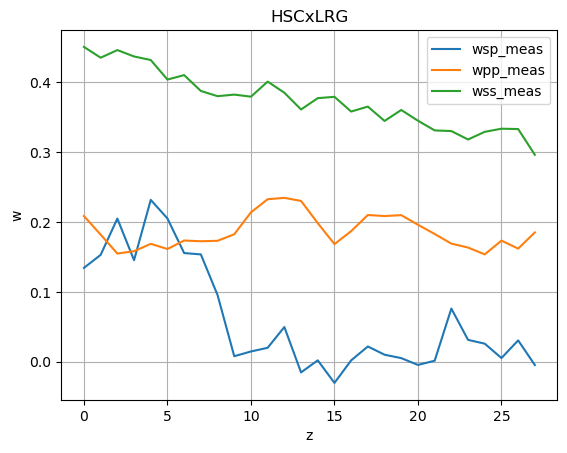

In [23]:
#wsp_meas, wpp_meas, wss_meas, hsc_bias, desi_bias, deltaz, zloc, result
plt.plot(data[0][:, 0], label='wsp_meas')
plt.plot(data[0][:, 1], label='wpp_meas') 
plt.plot(data[0][:, 2], label='wss_meas')
plt.grid()
plt.legend()
plt.title('HSCxLRG')
plt.xlabel('z')
plt.ylabel('w')

Text(0.5, 1.0, 'Bias models as a function of redshift for tracers')

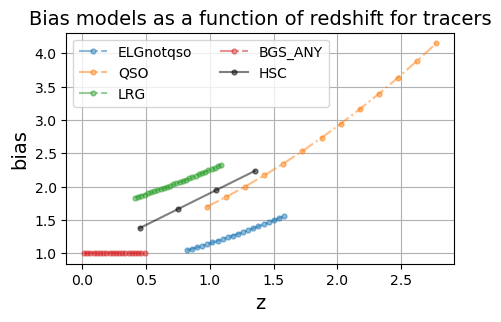

In [64]:
# plot the bias used
importlib.reload(resm)
plt.figure(figsize=(5, 3))
for tracer in ['ELGnotqso', 'QSO', 'LRG', 'BGS_ANY']:
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
    mids_tracer = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    bias = resm.desi_bias_evolution(z=mids_tracer, tracer=tracer)
    plt.plot(
        mids_tracer, 
        bias, 
        marker='o', 
        markersize=3.5, 
        linestyle='-.',  
        alpha=0.5,
        label=f'{tracer}'
    )
mids_hsc = bins_hsc[:-1] + np.diff(bins_hsc) / 2
plt.plot(
    mids_hsc,
    resm.hsc_bias_evolution(z=mids_hsc, b=0.95),
    marker='o',
    markersize=3.5,
    linestyle='-',
    alpha=0.5,
    label='HSC',
    color='black'
)
plt.xlabel('z', fontsize=14)
plt.ylabel('bias', fontsize=14)
plt.grid()
plt.legend(ncols=2, loc='upper left', fontsize=10)
plt.title(f'Bias models as a function of redshift for tracers',  fontsize=14)

Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Computing n(z) for tracer LRG and tomo bin 1
Computing n(z) for tracer LRG and tomo bin 2
Computing n(z) for tracer LRG and tomo bin 3
Computing n(z) for tracer LRG and tomo bin 4
Computing n(z) for tracer LRG and tomo bin 1
Computing n(z) for tracer LRG and tomo bin 2
Computing n(z) for tracer LRG and tomo bin 3
Computing n(z) for tracer LRG and tomo bin 4
Computing n(z) for tracer LRG and tomo bin 1
Computi

Text(0.5, 0.98, 'Calibrated p(z) for HSC\nroot : results_2')

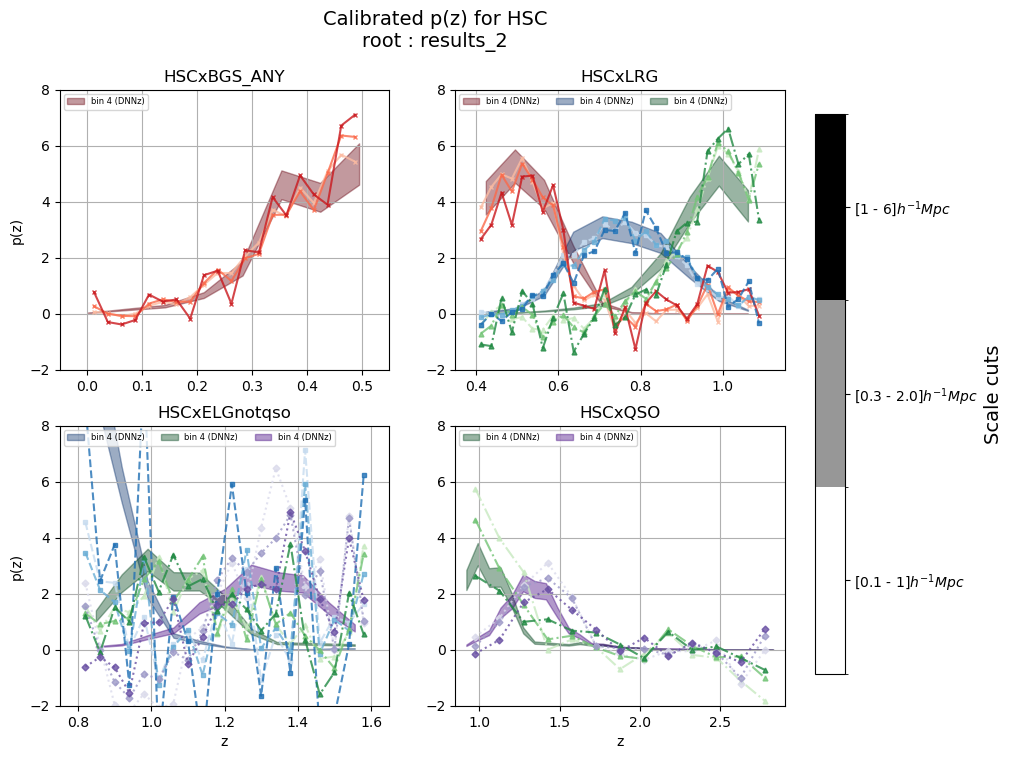

In [35]:
importlib.reload(resm)
scale_cuts = [[0.1, 1], [0.3, 2.0], [1, 6]]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']

bins_hsc = cf.CorrFileReader(
    path_dictionary['HSC'],
    ).get_bins('HSC')
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
fig.subplots_adjust(right=0.85) 
axs = axs.flatten()

for n, (ax, t) in enumerate(zip(axs, tracers)):
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mids = tomo_bin_dnnz[mask, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []
    ids_to_skip = []

    for k, sc in enumerate(scale_cuts):
        nz = []
        for i in range(1, 5):
            print(f"Computing n(z) for tracer {t} and tomo bin {i}")
            nz.append(
                resm.full_npz_tomo(
                    path_dictionary=path_dictionary,
                    scale_cuts=sc,
                    tracer=t,
                    tomo_bin=i,
                    )
            )

        for i in range(4):
            if max(range_tracer[0], bins_hsc[i]) > min(range_tracer[1], bins_hsc[i+1]):
                ids_to_skip.append(i)
                continue
            ncurves = 0
            ax.plot(
                zval, 
                nz[i]/simpson(nz[i], x=zval), 
                marker=markers[i], 
                linestyle=linestyles[i],
                markersize=3.5,   
                alpha=0.8,
                color=colormaps[i]((k+1)/4),
                )

    for k in range(4):
        if k in ids_to_skip:
            continue
        ncurves += 1

        dnnz, mu, cov = resm.hsc_dnnz_error(tomo_bin_dnnz[mask, k+1], mids)

        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color=colormaps[k]((i+2)/5), 
            label=f'bin {i+1} (DNNz)',
            alpha=0.4
            )
    if n == 2 or n == 3: 
        ax.set_xlabel('z')
    if n == 0 or n == 2:
        ax.set_ylabel('p(z)')
    ax.grid()
    ax.legend(fontsize=6, ncols=4, loc='upper left')
    ax.set_title(f'HSCx{t}')
    ax.set_xlim(min(bins_tracer)-0.05, max(bins_tracer)+0.05)
    ax.set_ylim(-2, 8)

cmap = plt.cm.Greys
scale_levels = np.arange(0, len(scale_cuts)+1, 1)
norm = BoundaryNorm(boundaries=scale_levels, ncolors=cmap.N, extend='neither')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
scale_ticks = scale_levels[:-1] + 0.5
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax, ticks=scale_ticks)
cbar.set_ticklabels([f'[{sc[0]} - {sc[1]}]' + r'$h^{-1}Mpc$' for sc in scale_cuts])
cbar.set_label('Scale cuts', fontsize=14)

fig.suptitle(f'Calibrated p(z) for HSC\nroot : {ROOT.name}', fontsize=14)

In [ ]:
## Let's obtain the r_cc coefficient with the simulations for LRGxHSC
cf_hsc = cf.CorrFileReader(
    ROOT / 'results_sims' / f'minibins_sims_{desc}_sp0_025',
    )
cf_desi = cf.CorrFileReader(
    ROOT / 'results_sims' / f'autos_{desc}',
    )
cf_desixhsc = cf.CorrFileReader(
    ROOT / 'results_sims' / f'cross_{desc}',
    )

resm.pearson_rcc(
    path_dictionary=path_dictionary,
    scale_cuts=[0.5, 5.0],
    tracer='LRG',
    tomo_bin=1,
    sigmaj_corrections=sigmaj_corr,
    verbose=True,
    return_chunks=True
)